Detect all objects.

Mark CAR as ANOMALY.

Show red box on cars.

Show green box on other objects.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')  #connect drive to colab

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

'1000200783-removebg-preview (1)~2.png'
'48 Law of power '
 canva.pdf
 Classroom
'Colab Notebooks'
 Final_dataset
'Google AI Studio'
'https:  docs.go.txt'
'numberssystem a.pdf'
'python14 built-in-functions_copy.pdf'
 R
'Screenshot_20231111_185930_Digilocker (1).pdf'
 ship_2.zip
'Untitled document.gdoc'
'Untitled form.gform'
'UTTAMRATHORE_2024UEC1675 (1).pdf'
'UTTAMRATHORE_2024UEC1675 (2).pdf'
 UTTAMRATHORE_2024UEC1675.pdf


In [ ]:
#!rsync -a /content/drive/MyDrive/ship_2/ /content/ship_2/  for normal folder

In [ ]:
!unzip -l "/content/drive/MyDrive/ship_2.zip" | head -20

Archive:  /content/drive/MyDrive/ship_2.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-05-28 08:49   Final_dataset/
      152  2026-05-28 08:24   Final_dataset/data.yaml
        0  2026-05-28 05:47   Final_dataset/test/
        0  2026-05-28 08:20   Final_dataset/test/images/
  1963941  2026-05-28 08:20   Final_dataset/test/images/a_102.jpg
  1995399  2026-05-28 08:20   Final_dataset/test/images/a_1022.jpg
  2000278  2026-05-28 08:20   Final_dataset/test/images/a_104.jpg
  1963357  2026-05-28 08:20   Final_dataset/test/images/a_1042.jpg
  1949372  2026-05-28 08:20   Final_dataset/test/images/a_1047.jpg
  2188378  2026-05-28 08:20   Final_dataset/test/images/a_1052.jpg
  1958447  2026-05-28 08:20   Final_dataset/test/images/a_1054.jpg
  1921420  2026-05-28 08:20   Final_dataset/test/images/a_1061.jpg
  1925350  2026-05-28 08:20   Final_dataset/test/images/a_1062.jpg
  1934666  2026-05-28 08:20   Final_dataset/test/images/a_1068.jpg
  1914659  2

In [ ]:
!unzip -q "/content/drive/MyDrive/ship_2.zip" -d "/content/"

replace /content/Final_dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!ls /content/Final_dataset

data.yaml  test  train	valid


In [ ]:
!cat /content/Final_dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5

names:
  0: boat
  1: dock
  2: jetski
  3: lift
  4: wind/sup-board

In [ ]:
!find /content/Final_dataset -name "data.yaml"

/content/Final_dataset/data.yaml


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
len(os.listdir("/content/Final_dataset/train/images"))

2649

In [ ]:
model = YOLO("yolov8n.pt")  #nano version

model.train(
    data="/content/Final_dataset/data.yaml",
    epochs=10,  #30 times on data
    imgsz=640,  #resize to 640x640
    batch=16, #16 images processing at once
    device=0,  #gpu=0
    project="ship_project",
    name="test_run",
    exist_ok=True
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Final_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=test_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e64a3b6db0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

gpu mean  3.73 gb gpu

box loss  error in drawing object box

cls loss error in classification

dfl loss yolo box positioning error

instance current batch contain 16 labelled obj batch 38




In [ ]:
!find /content/runs -name "best.pt"  #check model created

/content/runs/detect/ship_project/test_run/weights/best.pt


best.pt best train model durin all epoch training epoch 1 70 % epoch 2 90% so take epoch 2  deployment/Testing  → best.pt
Continue Training   → last.pt

In [ ]:
!cp -r /content/runs/detect/ship_project /content/drive/MyDrive/  #save trained model to drive start from here now

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/detect/ship_project/test_run/weights/best.pt"
)   #we can load it any time

In [ ]:
import os

test_dir = "/content/Final_dataset/train/images"

image_path = os.path.join(
    test_dir,
    os.listdir(test_dir)[0]
)

print(image_path)  #check

/content/Final_dataset/train/images/b1_290.jpg


In [ ]:
import os
import random

test_dir = "/content/Final_dataset/test/images"

image_path = os.path.join(
    test_dir,
    random.choice(os.listdir(test_dir))
)

print(image_path)

/content/Final_dataset/test/images/r3_222.jpg


In [ ]:
results = model(image_path)[0]  #detect obj


image 1/1 /content/Final_dataset/test/images/r3_222.jpg: 384x640 3 boats, 7.9ms
Speed: 2.3ms preprocess, 7.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


Total Anomalies Detected: 3


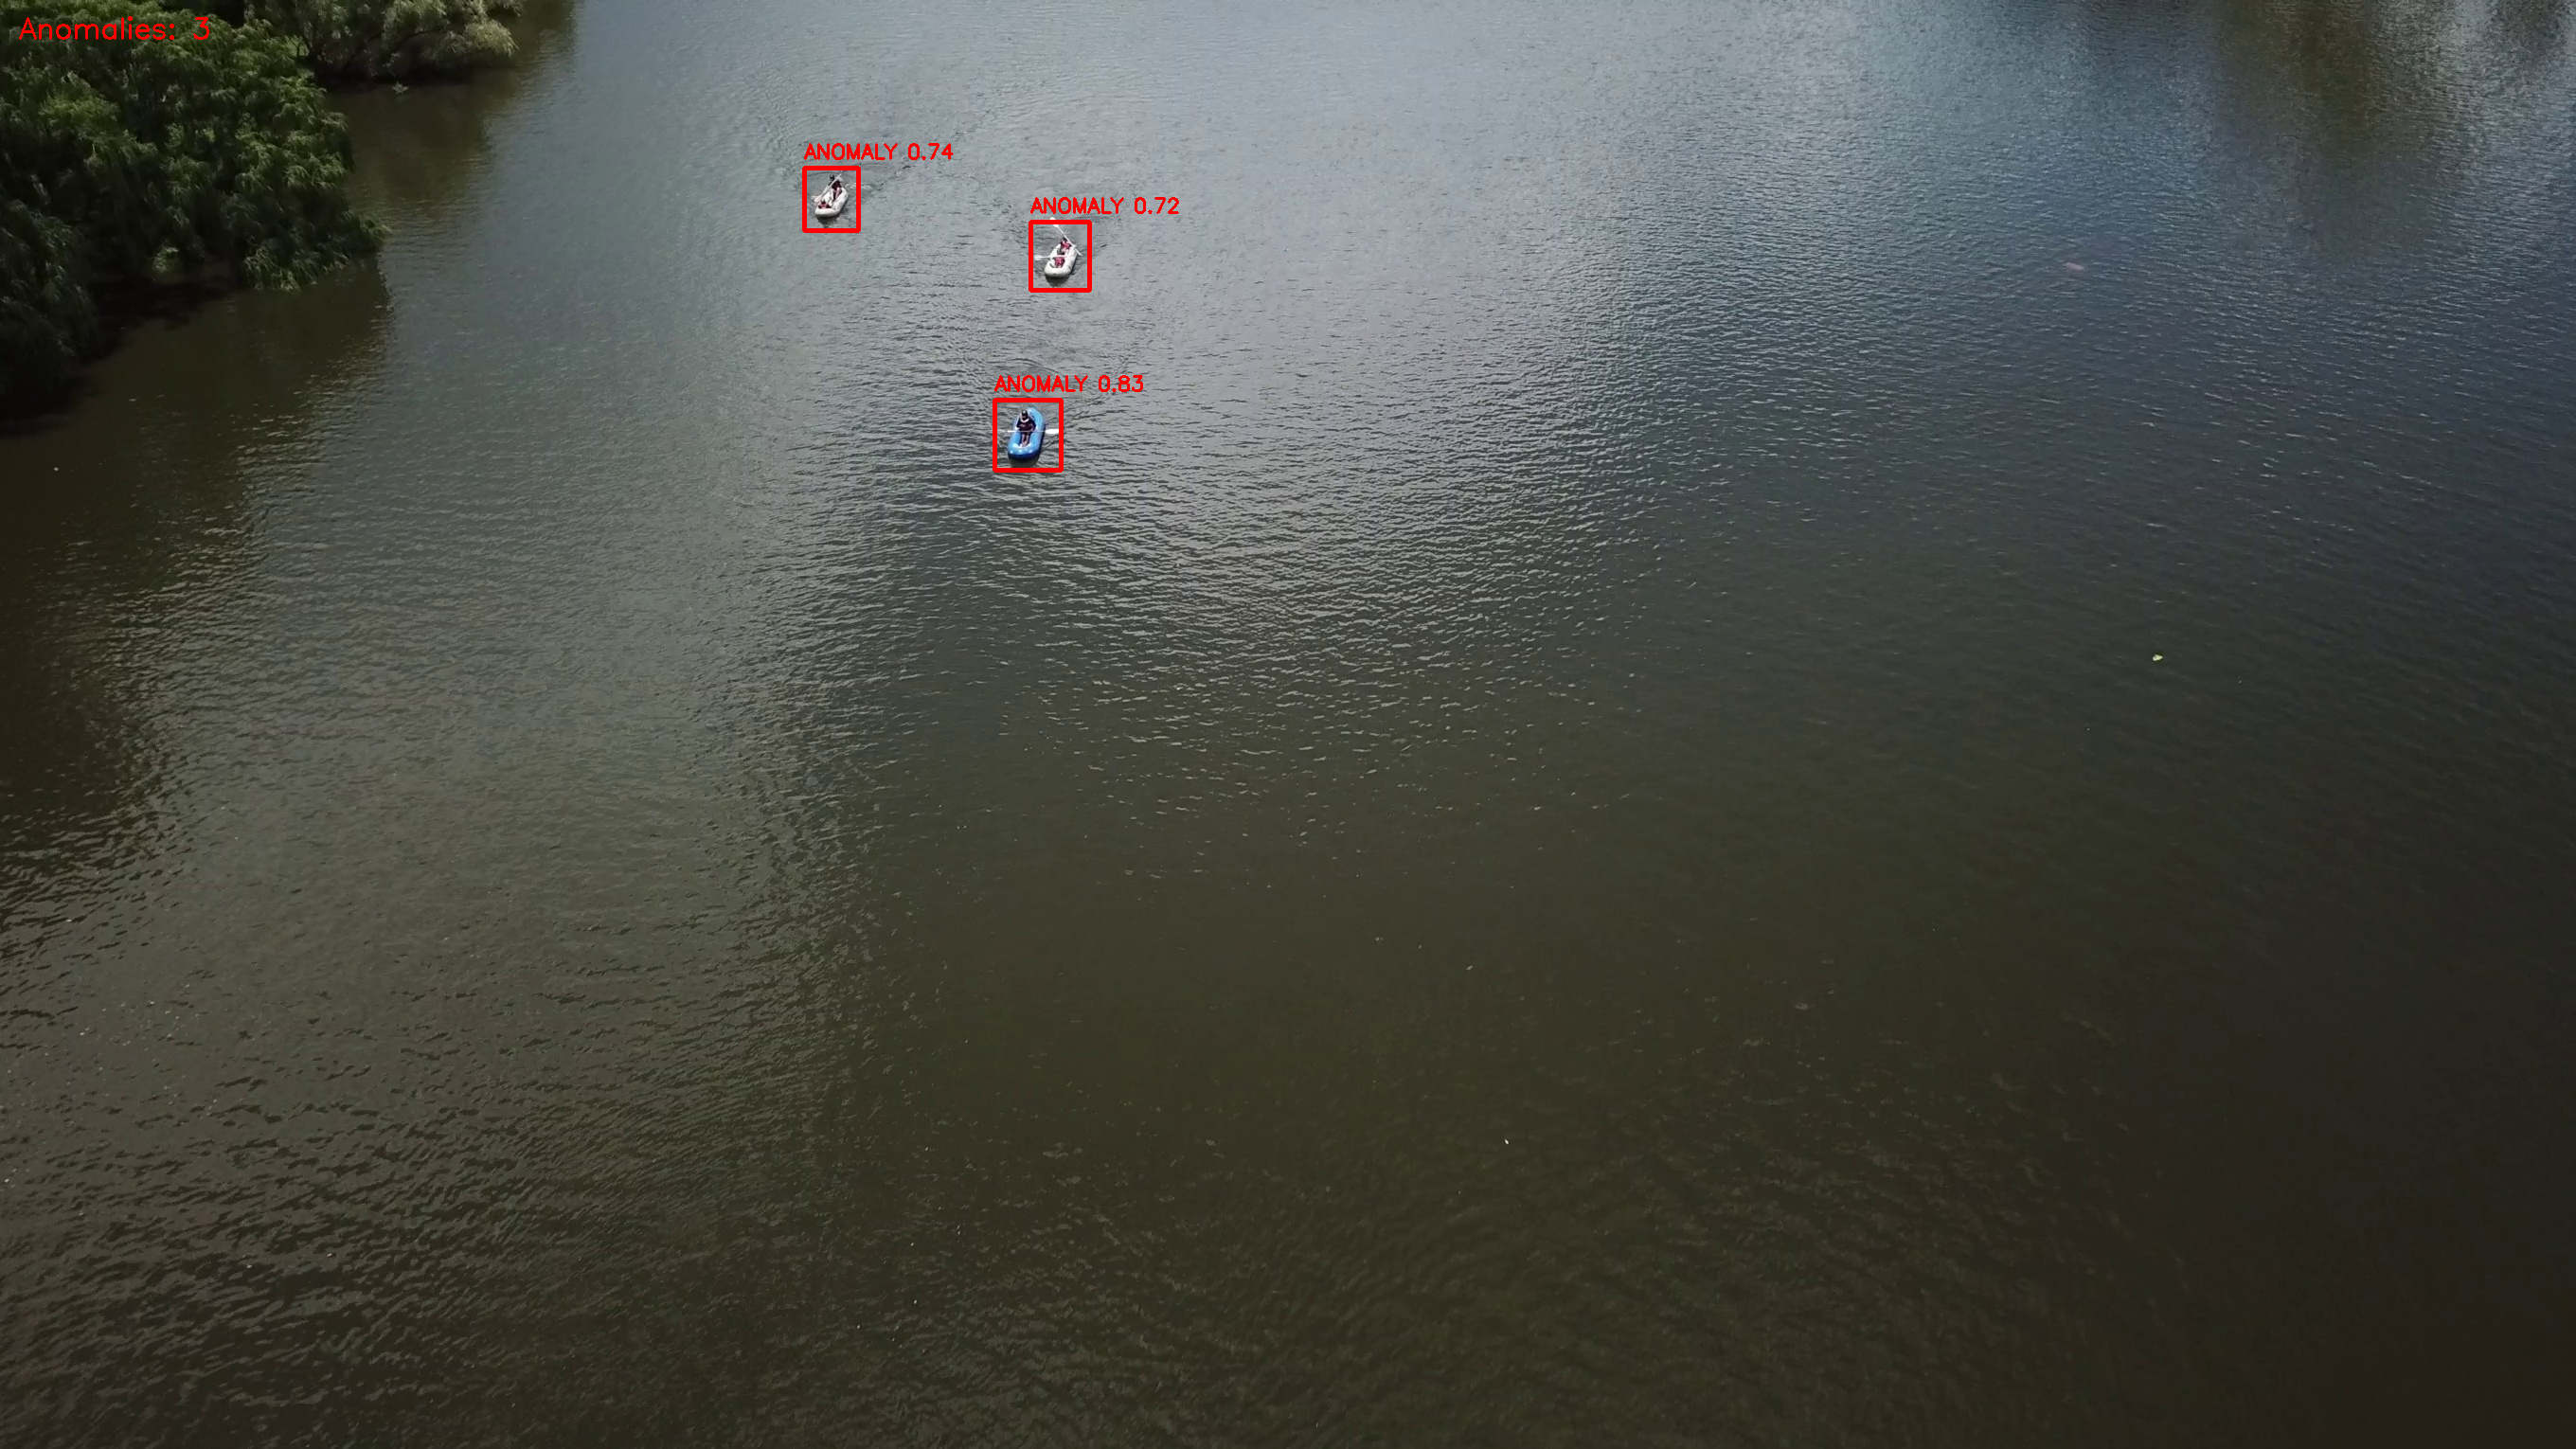

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread(image_path)

anomaly_count = 0

for box in results.boxes:

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    cls = int(box.cls[0])

    conf = float(box.conf[0])

    label = results.names[cls]

    if label == "boat":

        anomaly_count += 1

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0, 0, 255),
            3
        )

        cv2.putText(
            img,
            f"ANOMALY {conf:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 0, 255),
            2
        )

    else:

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            img,
            f"{label} {conf:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

# Summary on image
cv2.putText(
    img,
    f"Anomalies: {anomaly_count}",
    (20, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 0, 255),
    2
)

print("Total Anomalies Detected:", anomaly_count)

cv2_imshow(img)


image 1/1 /content/boat84.png: 640x640 (no detections), 7.3ms
Speed: 3.3ms preprocess, 7.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


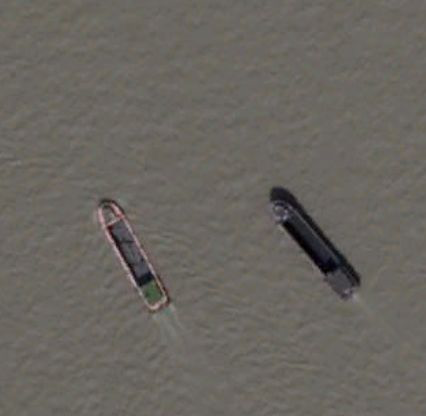

In [ ]:

results = model("/content/boat84.png")

results[0].show()  #uploaded pic

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/ship_project/test_run/weights/best.pt")

video_path = "/content/video.mp4"

results = model.predict(
    source=video_path,
    save=True,
    conf=0.25
)

ModuleNotFoundError: No module named 'ultralytics'